#**Task: Transfer learning (fine-tunning)** 

Take a pre-trained model Resnet18 and finetune it on the CIFAR10 dataset available from the Pytorch library: `torchvision.datasets.CIFAR10`.

Load a ResNet18 model with the learned weights using torchvision library: 
`resnet18 = models.resnet18(pretrained=True)`. This model was trained on the ImageNet dataset to classify 1000 object classes. Replace the final classification layer to perform a 10-class classification problem on the CIFAR10 dataset. You should try the two flavors of transfer learning, i.e. (1) freezing all the ResNet18 layers (feature extraction) and training the final classification layer; (2) finetuning all ResNet18 layers together with the final classification layer. Print the performance of the two models on the train and test sets.

Solution to Transfer Learning for Computer Vision Tutorial
==============================================

The solution is based on the tutorials:



In [ ]:
#CIFAR tutorial: https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

In [ ]:
#Transfer learning tutorial: https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html?highlight=transfer%20learning

In [ ]:
#All rights reserved


Loading CIFAR10 dataset
=====================

For vision, there is a package called
``torchvision``, that has data loaders for common datasets such as
ImageNet, CIFAR10, MNIST, etc. and data transformers for images, viz.,
``torchvision.datasets`` and ``torch.utils.data.DataLoader``.

This provides a huge convenience and avoids writing boilerplate code.

For this tutorial, we will use the CIFAR10 dataset.
It has the classes: ‘airplane’, ‘automobile’, ‘bird’, ‘cat’, ‘deer’,
‘dog’, ‘frog’, ‘horse’, ‘ship’, ‘truck’. The images in CIFAR-10 are of
size 3x32x32, i.e. 3-channel color images of 32x32 pixels in size.

Using ``torchvision``, it’s extremely easy to load CIFAR10.


In [ ]:
%matplotlib inline

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

In [ ]:
transform = {
    'train': transforms.Compose([
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


batch_size = 32

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform['train'])
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform['test'])
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

  0%|          | 0/170498071 [00:00<?, ?it/s]

Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


The output of torchvision datasets are PILImage images of range [0, 1].
We transform them to Tensors of normalized range. The normalisation is in terms of mean RGB intensities of the ImageNet dataset. ImageNet was used to pre-train the NNs models we will use in this tutorial.



Let us show some of the training images



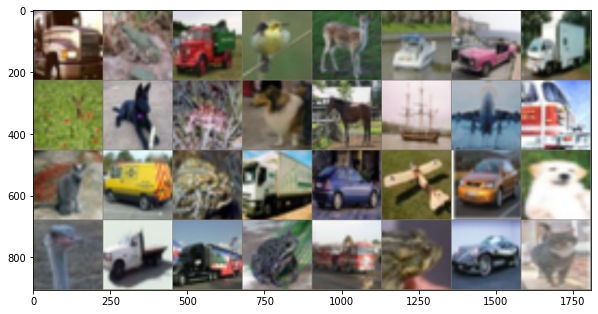

truck frog  truck bird  deer  ship  car   truck deer  dog   frog  dog   horse ship  plane truck cat   car   frog  truck car   plane car   dog   bird  truck truck frog  truck frog  car   cat  


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.figure(figsize=(10, 10))
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# get some random training images
dataiter = iter(trainloader)
images, labels = dataiter.next()

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))



The two major transfer learning scenarios look as follows:

-  **PART 1: Finetuning the convnet**: Instead of random initialization, we
   initialize the network with a pretrained network, like the one that is
   trained on imagenet 1000 dataset. Rest of the training looks as
   usual.
-  **PART 2: ConvNet as fixed feature extractor**: Here, we will freeze the weights
   for all of the network except that of the final fully connected
   layer. This last fully connected layer is replaced with a new one
   with random weights and only this layer is trained.


PART 1: Finetuning the convnet
----------------------

**Load the data**

Load a pretrained NNs model (ResNet18) and reset final fully connected layer.






In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, models, transforms
import torch.optim as optim
from torch.optim import lr_scheduler

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, 10)

model_ft = model_ft.to(device)
#print(model_ft)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

**Train the network for 5 epochs**



In [ ]:
for epoch in range(5):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)


        # zero the parameter gradients
        optimizer_ft.zero_grad()

        # forward + backward + optimize
        outputs = model_ft(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_ft.step()

        # print statistics
        running_loss += loss.item()
        if i % 100 == 99:    # print every 100 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,   100] loss: 0.073
[1,   200] loss: 0.033
[1,   300] loss: 0.024
[1,   400] loss: 0.020
[1,   500] loss: 0.018
[1,   600] loss: 0.015
[1,   700] loss: 0.014
[1,   800] loss: 0.013
[1,   900] loss: 0.014
[1,  1000] loss: 0.014
[1,  1100] loss: 0.013
[1,  1200] loss: 0.013
[1,  1300] loss: 0.014
[1,  1400] loss: 0.013
[1,  1500] loss: 0.011
[2,   100] loss: 0.009
[2,   200] loss: 0.010
[2,   300] loss: 0.009
[2,   400] loss: 0.009
[2,   500] loss: 0.009
[2,   600] loss: 0.009
[2,   700] loss: 0.008
[2,   800] loss: 0.009
[2,   900] loss: 0.009
[2,  1000] loss: 0.008
[2,  1100] loss: 0.008
[2,  1200] loss: 0.007
[2,  1300] loss: 0.009
[2,  1400] loss: 0.008
[2,  1500] loss: 0.008
[3,   100] loss: 0.006
[3,   200] loss: 0.006
[3,   300] loss: 0.006
[3,   400] loss: 0.006
[3,   500] loss: 0.006
[3,   600] loss: 0.006
[3,   700] loss: 0.005
[3,   800] loss: 0.006
[3,   900] loss: 0.006
[3,  1000] loss: 0.005
[3,  1100] loss: 0.005
[3,  1200] loss: 0.006
[3,  1300] loss: 0.006
[3,  1400] 

Let's quickly save our trained model:



In [ ]:
PATH = './cifar_net.pth'
torch.save(model_ft.state_dict(), PATH)


**Test the network on the test data**


We will check this by predicting the class label that the neural network
outputs, and checking it against the ground-truth. If the prediction is
correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get familiar.



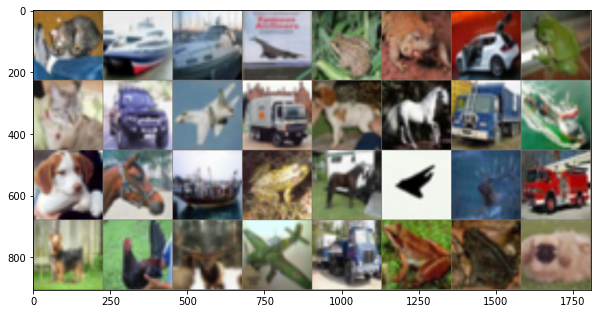

GroundTruth:  cat   ship  ship  plane frog  frog  car   frog  cat   car   plane truck dog   horse truck ship  dog   horse ship  frog  horse plane deer  truck dog   bird  deer  plane truck frog  frog  dog  


In [ ]:
dataiter = iter(testloader)
images, labels = dataiter.next()


# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(32)))

Next, let's load back in our saved model (note: saving and re-loading the model
wasn't necessary here, we only did it to illustrate how to do so):



In [ ]:
net = model_ft
net.load_state_dict(torch.load(PATH))

<All keys matched successfully>

Okay, now let us see what the neural network thinks these examples above are:



In [ ]:
images = images.to(device)
labels = labels.to(device)

outputs = net(images)
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(32)))

Predicted:  cat   ship  ship  plane frog  frog  car   frog  cat   car   plane truck dog   horse truck ship  dog   horse ship  frog  horse plane deer  truck dog   bird  deer  plane truck frog  frog  dog  


The results seem pretty good.

Let us look at how the network performs on the whole test set.



In [ ]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
 
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 94 %


That looks impressive. Q: what are the classes that performed well, and the classes that did
not perform well?



In [ ]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 94.4 %
Accuracy for class: car   is 96.7 %
Accuracy for class: bird  is 91.9 %
Accuracy for class: cat   is 87.8 %
Accuracy for class: deer  is 96.7 %
Accuracy for class: dog   is 90.9 %
Accuracy for class: frog  is 97.9 %
Accuracy for class: horse is 95.4 %
Accuracy for class: ship  is 96.9 %
Accuracy for class: truck is 95.8 %


PART 2: ConvNet as fixed feature extractor
----------------------------------

Here, we need to freeze all the network except the final layer. We need
to set ``requires_grad = False`` to freeze the parameters so that the
gradients are not computed in ``backward()``.



In [ ]:
model_conv = torchvision.models.resnet18(pretrained=True)
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 10)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

**Train the network for 5 epochs**



In [ ]:
for epoch in range(5):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer_conv.zero_grad()

        # forward + backward + optimize
        outputs = model_conv(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_conv.step()

        # print statistics
        running_loss += loss.item()
        if i % 100 == 99:    # print every 100 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

Finished Training



**Test the network on the test data**


We will check this by predicting the class label that the neural network
outputs, and checking it against the ground-truth. If the prediction is
correct, we add the sample to the list of correct predictions.



In [ ]:
net = model_conv

In [ ]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
 
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 74 %


That looks way better than chance, which is 10% accuracy (randomly picking
a class out of 10 classes).
Seems like the network learnt something.

Q: what are the classes that performed well, and the classes that did
not perform well?



In [ ]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 76.1 %
Accuracy for class: car   is 81.9 %
Accuracy for class: bird  is 62.9 %
Accuracy for class: cat   is 59.3 %
Accuracy for class: deer  is 65.6 %
Accuracy for class: dog   is 76.9 %
Accuracy for class: frog  is 82.5 %
Accuracy for class: horse is 75.6 %
Accuracy for class: ship  is 83.1 %
Accuracy for class: truck is 85.3 %
